In [1]:
import numpy
import pandas, cv2, os
import matplotlib.pyplot as plt

In [2]:
mask_data = pandas.read_csv('/kaggle/input/segmentaion-anotation/yolo_annotations.csv')

In [3]:
mask_data

,study_id,series_id,instance_number,condition,level,x_min,y_min,x_max,y_max,class_id,img_width,img_height
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,317.831858,222.964602,327.831858,232.964602,0,640,640
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,315.571429,290.714286,325.571429,300.714286,0,640,640
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,318.030303,366.818182,328.030303,376.818182,0,640,640
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,330.292035,422.327434,340.292035,432.327434,0,640,640
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,348.415929,478.964602,358.415929,488.964602,0,640,640
...,...,...,...,...,...,...,...,...,...,...,...,...
48687,4290709089,4237840455,11,Left Neural Foraminal Narrowing,L1/L2,214.465940,92.831063,224.465940,102.831063,0,384,384
48688,4290709089,4237840455,12,Left Neural Foraminal Narrowing,L2/L3,200.340599,135.207084,210.340599,145.207084,0,384,384
48689,4290709089,4237840455,12,Left Neural Foraminal Narrowing,L3/L4,197.724796,176.013624,207.724796,186.013624,0,384,384
48690,4290709089,4237840455,12,Left Neural Foraminal Narrowing,L4/L5,197.933333,214.733333,207.933333,224.733333,0,384,384


In [4]:
os.makedirs('mask', exist_ok=True)

In [5]:
img_width, img_height, x_min, y_min, x_max, y_max, study_id, series_id, instance_number = (mask_data['img_width'], 
                                                                                           mask_data['img_height'], 
                                                                                           mask_data['x_min'], 
                                                                                           mask_data['y_min'], 
                                                                                           mask_data['x_max'], 
                                                                                           mask_data['y_max'], 
                                                                                           mask_data['study_id'], 
                                                                                           mask_data['series_id'], 
                                                                                           mask_data['instance_number'])

In [6]:
for imgwidth, imgheight, xmin, ymin, xmax, ymax, studyid, seriesid, instancenumber in zip(img_width, img_height, x_min, y_min, x_max, y_max, study_id, series_id, instance_number):
    if os.path.exists(f'mask/{studyid}_{seriesid}_{instancenumber}.jpg'):
        data = cv2.imread(f'mask/{studyid}_{seriesid}_{instancenumber}.jpg')
    else:
        cv2.imwrite('mask.jpg', numpy.array([[255, 255, 255]]*(imgwidth*imgheight)).reshape(imgwidth, imgheight, 3))
        data = cv2.imread('mask.jpg')
        
    data = cv2.rectangle(cv2.cvtColor(data, cv2.COLOR_RGB2BGR), (round(xmin), round(ymin)), (round(xmax), round(ymax)), (0, 0, 0), -1)
    cv2.imwrite(f'mask/{studyid}_{seriesid}_{instancenumber}.jpg', data)

[ WARN:0@0.639] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


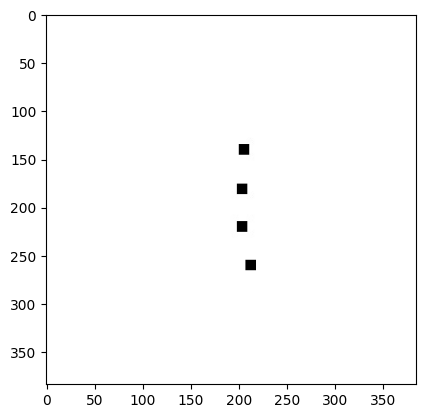

In [7]:
plt.imshow(data)
plt.show()